# Model Training (qubit-TransmonCross-Hamiltonian_params)
## Hamiltonian Parameters --> Quantum Metal

Inverse model with surrogate-defined loss for the Transmon Cross dataset.

Instead of training the inverse model to directly predict Quantum Metal parameters and comparing
against ground truth SQuADDS data (which penalizes valid alternative solutions), we chain the
inverse model with a frozen surrogate and compute loss in Hamiltonian space.

**Pipeline:** Hamiltonian_input -> Inverse MLP -> Qiskit_params -> ScalerConversion -> Surrogate(frozen) -> Hamiltonian_reconstructed

**Loss:** MSE(Hamiltonian_input, Hamiltonian_reconstructed) + penalty for out-of-range predictions

The Transmon Cross dataset has all continuous parameters,
but the inverse model (ml_00/ml_01) and surrogate (ml_10/ml_11) use different scalers.
A ScalerConversionLayer handles the transform between scalers.

## Configuration

In [1]:
from pathlib import Path
## the parameter file has the hyperparameters
## start there if you want to change the setup

from parameters_surrogate_defined_loss import *

if KERAS_TUNER == True:
    print("keras tuner is ON with {} trials".format(KERAS_TUNER_TRIALS))
else:
    print("keras tuner is OFF")

keras tuner is OFF


## Library

In [2]:
import os, gc, joblib, json, time, sys, math, csv

## keep the tensorflow warnings down
## comment this out if you want the warnings back
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
from pandas import json_normalize
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from tensorflow.python.client import device_lib

## imports that come up later
from tensorflow.keras import Sequential
from keras_tuner import BayesianOptimization
import keras_tuner as kt

seed = 0

## if the seed stays the same, the random numbers stay the same too
## you get the same random numbers every run
tf.random.set_seed(seed)
np.random.seed(seed)

## Check GPU

In [3]:
## check what hardware tensorflow can see
print(device_lib.list_local_devices())

## run !{sys.executable} m pip install u pip
## run !{sys.executable} m pip install tensorflow[andcuda]
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')
for gpu in gpus:
    print(f'  {gpu}')

## check the cuda packages
!{sys.executable} -m pip list | egrep "tensorflow|nvidia-(cuda|cudnn|cublas|nccl)"

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 12828518177073445377
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 40254177280
locality {
  bus_id: 1
  links {
  }
}
incarnation: 16210660654974395468
physical_device_desc: "device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:06:00.0, compute capability: 8.0"
xla_global_id: 416903419
]
GPUs available: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


I0000 00:00:1778020263.185147  677750 gpu_device.cc:2020] Created device /device:GPU:0 with 38389 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:06:00.0, compute capability: 8.0


nvidia-cublas-cu11        11.11.3.6
nvidia-cublas-cu12        12.9.1.4
nvidia-cuda-cupti-cu11    11.8.87
nvidia-cuda-cupti-cu12    12.9.79
nvidia-cuda-nvcc-cu12     12.9.86
nvidia-cuda-nvrtc-cu11    11.8.89
nvidia-cuda-nvrtc-cu12    12.9.86
nvidia-cuda-runtime-cu11  11.8.89
nvidia-cuda-runtime-cu12  12.9.79
nvidia-cudnn-cu11         9.1.0.70
nvidia-cudnn-cu12         9.17.1.4
nvidia-nccl-cu11          2.21.5
nvidia-nccl-cu12          2.29.2
tensorflow                2.20.0
tensorflow-datasets       4.8.3+nightly
tensorflow-estimator      2.11.0
tensorflow-metadata       1.13.1


## Dataset

### Load

In [4]:
## load the data saved from ml_00 notebook (inverse model format)
## for the transmon cross, ml_00 uses 'one_hot' encoding label but all params are continuous

## inputs are the hamiltonian values (what we want to invert)
X_train = np.load(f'{DATA_DIR}/npy/x_train_one_hot_encoding_augmented.npy', allow_pickle=True)
X_val   = np.load(f'{DATA_DIR}/npy/x_val_one_hot_encoding_augmented.npy', allow_pickle=True)
X_test  = np.load(f'{DATA_DIR}/npy/x_test_one_hot_encoding_augmented.npy', allow_pickle=True)

## qiskit metal params (all continuous for transmon cross)
y_train = np.load(f'{DATA_DIR}/npy/y_train_one_hot_encoding_augmented.npy', allow_pickle=True)
y_val   = np.load(f'{DATA_DIR}/npy/y_val_one_hot_encoding_augmented.npy', allow_pickle=True)
y_test  = np.load(f'{DATA_DIR}/npy/y_test_one_hot_encoding_augmented.npy', allow_pickle=True)

## column names
with open(str(Path(METADATA_DIR) / 'X_names'), 'r') as f:
    Hamiltonian_column_names = f.read().splitlines()

qiskit_param_names = np.load(str(Path(METADATA_DIR) / 'y_columns.npy'), allow_pickle=True).astype(str).tolist()

print(f'Inputs (Hamiltonian):     {X_train.shape[1]} columns')
print(f'Outputs (Qiskit params):  {y_train.shape[1]} columns')
print(f'Training samples: {len(X_train)}')
print(f'\nHamiltonian columns: {Hamiltonian_column_names}')
print(f'Qiskit param columns: {qiskit_param_names}')

X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_val   = X_val.astype('float32')
y_val   = y_val.astype('float32')
X_test  = X_test.astype('float32')
y_test  = y_test.astype('float32')

Inputs (Hamiltonian):     2 columns
Outputs (Qiskit params):  3 columns
Training samples: 1353

Hamiltonian columns: ['qubit_frequency_GHz', 'anharmonicity_MHz']
Qiskit param columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']


### Training schedule

In [5]:
steps_per_epoch = int(np.ceil(len(X_train) / TRAIN_BATCH_SIZE))
LR_DECAY_STEPS = steps_per_epoch * 20
print(f'Steps per epoch {steps_per_epoch}')
print(f'LR decay steps {LR_DECAY_STEPS}')

Steps per epoch 11
LR decay steps 220


## MLP

### Create model

### Make scaler conversion layer

The inverse model (ml_00/ml_01) and surrogate model (ml_10/ml_11) may use different MinMaxScalers
because they were fit on different data splits or processing pipelines.
This layer does the affine transform: `linear_scaled = oh_scaled * scale_a + scale_b`
to convert between the two scaler spaces. All operations are differentiable.

In [6]:
## determine column mapping between inverse model output and surrogate input
## the inverse model outputs qiskit params in ml_00 scaler space
## the surrogate expects them in ml_10 scaler space

n_qiskit_params = y_train.shape[1]
print(f'Number of Quantum Metal params: {n_qiskit_params}')
print(f'Param names: {qiskit_param_names}')

## compute affine conversion constants between ml_00 and ml_10 scaler spaces
## for each param linear_scaled = oh_scaled * scale_a + scale_b
## where scale_a = oh_range / lin_range, scale_b = (oh_min lin_min) / lin_range

scale_a = np.ones(n_qiskit_params, dtype=np.float32)
scale_b = np.zeros(n_qiskit_params, dtype=np.float32)

for i, col in enumerate(qiskit_param_names):
    ## try loading both scalers
    oh_path = f'{SCALERS_DIR}/scaler_y_{col}_one_hot_encoding.save'
    lin_path = f'{SCALERS_DIR}/scaler_y_linear_{col}.save'

    if os.path.exists(oh_path) and os.path.exists(lin_path):
        oh_sc  = joblib.load(oh_path)
        lin_sc = joblib.load(lin_path)
        oh_min, oh_range   = float(oh_sc.data_min_[0]), float(oh_sc.data_range_[0])
        lin_min, lin_range = float(lin_sc.data_min_[0]), float(lin_sc.data_range_[0])
        scale_a[i] = oh_range / lin_range
        scale_b[i] = (oh_min - lin_min) / lin_range
        print(f'  {col}: a={scale_a[i]:.6f}, b={scale_b[i]:.6f}')
    else:
        print(f'  {col}: using identity (missing scaler file)')

if np.allclose(scale_a, 1.0) and np.allclose(scale_b, 0.0):
    print('\nScalers are identical - conversion is identity (no transform needed)')
else:
    print('\nScalers differ - affine conversion will be applied')

## load and freeze the surrogate model so its not updated during training
SURROGATE_PATH = str(Path(MODEL_DIR) / 'best_keras_model_model2_surrogate.keras')
surrogate = load_model(SURROGATE_PATH, compile=False)

## freeze it
surrogate.trainable = False
for layer in surrogate.layers:
    layer.trainable = False

surr_input_dim = surrogate.input_shape[-1]
print(f'\nSurrogate loaded from {SURROGATE_PATH}')
print(f'Surrogate expects {surr_input_dim} inputs, inverse model outputs {n_qiskit_params}')
assert surr_input_dim == n_qiskit_params, f'Dimension mismatch!'
surrogate.summary()

## build the scaler conversion layer
## converts inverse model output (ml_00 scaler space) to surrogate input (ml_10 scaler space)
## all operations are differentiable so gradients flow through

class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault('trainable', False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = dict(
            scale_a=list(scale_a) if hasattr(scale_a, '__iter__') else scale_a,
            scale_b=list(scale_b) if hasattr(scale_b, '__iter__') else scale_b)

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config

scaler_converter = ScalerConversionLayer(
    scale_a=scale_a, scale_b=scale_b, name='scaler_conversion')

## quick sanity test
test_input = tf.constant(y_train[:3])
test_output = scaler_converter(test_input)
print(f'Conversion test: input shape {test_input.shape} -> output shape {test_output.shape}')

## penalizes the inverse model for predicting qiskit metal values outside
## the training data range [0, 1] (since data is MinMaxScaled).
## this prevents the model from finding "adversarial" inputs to the surrogate
## that look good in hamiltonian parameter space but don't correspond to real designs.

PENALTY_WEIGHT = 0.1  ## tune this increase if params are still wild, decrease if reconstruction suffers

def qiskit_range_penalty(y_true_dummy, y_pred):
    """Penalize predictions outside [0, 1] range.
    y_true_dummy is ignored (we pass zeros as dummy targets).
    y_pred is the inverse model's raw output in scaled space."""
    below = tf.nn.relu(-y_pred)
    above = tf.nn.relu(y_pred - 1.0)
    return tf.reduce_mean(below ** 2 + above ** 2)

## prebuild dummy targets for training
dummy_y_train = np.zeros_like(y_train)
dummy_y_val   = np.zeros_like(y_val)
dummy_y_test  = np.zeros_like(y_test)

print(f'Penalty weight: {PENALTY_WEIGHT}')
print(f'Dummy targets shape: {dummy_y_train.shape}')

Number of Quantum Metal params: 3
Param names: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']
  design_options.connection_pads.readout.claw_length: a=1.000000, b=0.000000
  design_options.connection_pads.readout.ground_spacing: a=1.000000, b=0.000000
  design_options.cross_length: a=1.000000, b=0.000000

Scalers are identical - conversion is identity (no transform needed)


I0000 00:00:1778020264.012912  677750 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38389 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:06:00.0, compute capability: 8.0



Surrogate loaded from /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_model2_surrogate.keras
Surrogate expects 3 inputs, inverse model outputs 3


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 736)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 736)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 736)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │         1,474 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,418 (17.26 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,418 (17.26 KB)

Conversion test: input shape (3, 3) -> output shape (3, 3)
Penalty weight: 0.1
Dummy targets shape: (1353, 3)


### Create Model by Hand

In [7]:
## just checkin to make sure everything looks good still, we want float32
print(X_train.dtype, X_train.shape)
print(y_train.dtype, y_train.shape)

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    ## model shape string for file naming
    model_shape = f'surrogate_loss_{X_train.shape[1]}in_{y_train.shape[1]}out'
    print(model_shape)

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    ## build inverse model that takes hamiltonian > qiskit metal params
    inverse_model = Sequential(name='inverse_model')
    inverse_model.add(Input(shape=(X_train.shape[1],), name='Hamiltonian_input'))

    for i, n in enumerate(NEURONS_PER_LAYER):
        inverse_model.add(Dense(n, name='fc{}'.format(i),
                        kernel_initializer='lecun_uniform',
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
        inverse_model.add(LeakyReLU(negative_slope=0.01, name='leaky_relu{}'.format(i)))
        inverse_model.add(Dropout(rate=TRAIN_DROPOUT_RATE, name='dropout{}'.format(i)))

    ## output layer predicts qiskit metal params
    inverse_model.add(Dense(y_train.shape[1], activation='linear', name='qiskit_output',
                    kernel_initializer='lecun_uniform'))

    ## twooutput combined model
    ## output 1 reconstructed hamiltonian (through frozen surrogate) main loss
    ## output 2 raw qiskit params range penalty loss
    combined_input = Input(shape=(X_train.shape[1],), name='combined_input')
    predicted_qiskit = inverse_model(combined_input)
    predicted_qiskit_converted = scaler_converter(predicted_qiskit)  ## affine conversion
    reconstructed_Hamiltonian = surrogate(predicted_qiskit_converted)
    model = Model(
        inputs=combined_input,
        outputs=[reconstructed_Hamiltonian, predicted_qiskit],
        name='combined_model'
    )

    print('Inverse model (outputs Quantum Metal params):')
    inverse_model.summary()
    print('\nCombined model (two outputs: Hamiltonian reconstruction + Qiskit params for penalty):')
    model.summary()

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=LR_INITIAL,  
        decay_steps=LR_DECAY_STEPS,        
        decay_rate=LR_DECAY_RATE,          
        staircase=LR_STAIRCASE             
    )

    ## two losses reconstruction + range penalty on qiskit params
    model.compile(
        optimizer=tf.optimizers.Adam(learning_rate=lr_schedule),  
        loss=[TRAIN_LOSS, qiskit_range_penalty],
        loss_weights=[1.0, PENALTY_WEIGHT],
        metrics={model.output_names[0]: [TRAIN_LOSS]}
    )

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
    best_model_file = str(Path(MODEL_DIR) / '{}_best_model.keras').format(model_shape)
    last_model_file = str(Path(MODEL_DIR) / '{}_last_model.keras').format(model_shape)
    print('Best model will be saved to:', best_model_file)

float32 (1353, 2)
float32 (1353, 3)
surrogate_loss_2in_3out
Inverse model (outputs Quantum Metal params):


Model: "inverse_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu1 (LeakyReLU)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu2 (LeakyReLU)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qiskit_output (Dense)           │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,307 (9.01 KB)

 Trainable params: 2,307 (9.01 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inverse_model (Sequential)      │ (None, 3)              │         2,307 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaler_conversion               │ (None, 3)              │             0 │
│ (ScalerConversionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 2)              │         4,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,725 (26.27 KB)

 Trainable params: 2,307 (9.01 KB)

 Non-trainable params: 4,418 (17.26 KB)

Best model will be saved to: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/surrogate_loss_2in_3out_best_model.keras


Enable training (`train_and_save`) to overwrite the model file.

In [8]:
train_and_save = True

We use Adam optimizer, minimize the loss specified in parameters, and early stop.

#### Training

In [9]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    class TrainingPlot(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.losses = []
            self.val_losses = []
        def on_epoch_end(self, epoch, logs=None):
            self.losses.append(logs.get('loss'))
            self.val_losses.append(logs.get('val_loss'))

    class LearningRateMonitor(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.learning_rates = []
        def on_epoch_end(self, epoch, logs=None):
            lr = self.model.optimizer.learning_rate
            if callable(lr):
                lr = lr(self.model.optimizer.iterations)
            self.learning_rates.append(float(tf.keras.backend.get_value(lr)))


## train the model two targets
## 1. hamiltonian reconstruction (input hamiltonian is the target)
## 2. dummy zeros for the penalty loss (penalty only uses predictions, ignores target)
history = None  
if not KERAS_TUNER and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    if train_and_save: 
        early_stopping = EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=TRAIN_EARLY_STOPPING_PATIENCE,
            verbose=1
        )

        plot_callback = TrainingPlot()
        lr_monitor = LearningRateMonitor()

        model_checkpoint = ModelCheckpoint(
            filepath=best_model_file,          
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            verbose=0
        )

        history = model.fit(
            np.asarray(X_train),
            [np.asarray(X_train), dummy_y_train],
            epochs=400,                   
            batch_size=TRAIN_BATCH_SIZE,  
            validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),  
            callbacks=[early_stopping, model_checkpoint, plot_callback, lr_monitor],  
            verbose=1
        )

        model.save(last_model_file)

Epoch 1/400
 1/11 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - inverse_model_loss: 0.0140 - loss: 1.4427 - sequential_loss: 1.4315 - sequential_mae: 1.4315

I0000 00:00:1778020269.466684  678160 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 619ms/step - inverse_model_loss: 0.0038 - loss: 0.9210 - sequential_loss: 0.8914 - sequential_mae: 0.9108 - val_inverse_model_loss: 0.0010 - val_loss: 0.4007 - val_sequential_loss: 0.3918 - val_sequential_mae: 0.3909
Epoch 2/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - inverse_model_loss: 5.3890e-04 - loss: 0.2533 - sequential_loss: 0.2398 - sequential_mae: 0.2436 - val_inverse_model_loss: 8.3251e-04 - val_loss: 0.1446 - val_sequential_loss: 0.1435 - val_sequential_mae: 0.1349
Epoch 3/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - inverse_model_loss: 4.5670e-04 - loss: 0.1241 - sequential_loss: 0.1145 - sequential_mae: 0.1145 - val_inverse_model_loss: 9.1868e-04 - val_loss: 0.1069 - val_sequential_loss: 0.1012 - val_sequential_mae: 0.0973
Epoch 4/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - inverse_model_loss: 5.8551e-04 - loss: 0.1162 - sequential_loss: 0.1068 - sequential_mae: 0.1066 - val_inverse_model_loss: 0.0014 - val_loss: 0.0993 - val_sequential_

Load the saved best model and use it from now on.

In [10]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    model = load_model(best_model_file, custom_objects={
        'ScalerConversionLayer': ScalerConversionLayer,
        'qiskit_range_penalty': qiskit_range_penalty})

### Parameter/architecture sweep model comparison

First compare the best checkpoint from the Keras tuner trials against the rerun model file. The normal architecture sweep is in the next code cell.


In [ ]:
if SWEEP_PARAM_NUM:
    Hamiltonian_dim = X_train.shape[1]
    qiskit_dim = y_train.shape[1]
    tuner_project_name = 'transmon_cross_surrogate_loss2'
    comparison_penalty_weight = PENALTY_WEIGHT
    comparison_metric = 'val_total_loss'

    custom_objects = {
        'ScalerConversionLayer': ScalerConversionLayer,
        'qiskit_range_penalty': qiskit_range_penalty,
    }

    def completed_tuner_trials():
        candidate_roots = [
            Path(KT_DIR) / tuner_project_name,
            Path(KT_DIR),
            Path(MODEL_DIR).parent / 'kt_dir2' / tuner_project_name,
        ]
        trial_rows = []
        for root in candidate_roots:
            if not root.exists():
                continue
            for trial_path in sorted(root.glob('trial_*/trial.json')):
                checkpoint_path = trial_path.parent / 'checkpoint.weights.h5'
                if not checkpoint_path.exists():
                    continue
                try:
                    trial_data = json.loads(trial_path.read_text())
                except Exception as exc:
                    print(f'Skipping unreadable trial file {trial_path}: {exc}')
                    continue
                if trial_data.get('status') != 'COMPLETED':
                    continue
                score = trial_data.get('score')
                if score is None or not np.isfinite(float(score)):
                    continue
                hp_values = dict(trial_data.get('hyperparameters', {}).get('values', {}))
                trial_rows.append({
                    'score': float(score),
                    'trial_path': trial_path,
                    'checkpoint_path': checkpoint_path,
                    'hp_values': hp_values,
                    'best_step': trial_data.get('best_step'),
                })
        if not trial_rows:
            searched = '\n'.join(str(path) for path in candidate_roots)
            raise FileNotFoundError(f'No completed Keras tuner trials with checkpoints found in:\n{searched}')
        return sorted(trial_rows, key=lambda row: row['score'])

    def load_frozen_surrogate_for_eval():
        surr = load_model(SURROGATE_PATH, compile=False)
        surr.trainable = False
        for layer in surr.layers:
            layer.trainable = False
        return surr

    def build_tuner_combined_model(hp_values):
        tf.keras.backend.clear_session()
        surr = load_frozen_surrogate_for_eval()
        converter = ScalerConversionLayer(
            scale_a=scale_a,
            scale_b=scale_b,
            name='scaler_conversion',
        )

        n_layers = int(hp_values['n_layers'])
        dropout_rate = float(hp_values.get('dropout_rate', 0.0))
        l2_reg = float(hp_values.get('l2_reg', 1e-4))
        use_batchnorm = bool(hp_values.get('use_batchnorm', False))
        neurons_per_layer = [int(hp_values[f'neurons_{i}']) for i in range(n_layers)]

        inv = Sequential(name='inverse_model')
        inv.add(Input(shape=(Hamiltonian_dim,), name='Hamiltonian_input'))
        for i, n_units in enumerate(neurons_per_layer):
            inv.add(Dense(
                n_units,
                name=f'fc{i}',
                kernel_initializer='he_normal',
                kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
            ))
            if use_batchnorm:
                inv.add(tf.keras.layers.BatchNormalization(name=f'bn{i}'))
            inv.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            inv.add(Dropout(rate=dropout_rate, name=f'dropout{i}'))
        inv.add(Dense(qiskit_dim, name='qiskit_output', kernel_initializer='he_normal'))

        combined_input = Input(shape=(Hamiltonian_dim,), name='combined_input')
        qiskit_out = inv(combined_input)
        qiskit_conv = converter(qiskit_out)
        Hamiltonian_recon = surr(qiskit_conv)
        return Model(combined_input, [Hamiltonian_recon, qiskit_out], name='combined_model')

    def get_inverse_model(candidate_model):
        try:
            return candidate_model.get_layer('inverse_model')
        except ValueError:
            return candidate_model

    def dense_architecture(candidate_model):
        inverse_model = get_inverse_model(candidate_model)
        return [
            int(layer.units)
            for layer in inverse_model.layers
            if isinstance(layer, Dense) and layer.name.startswith('fc')
        ]

    def output_tensors(candidate_model):
        outputs = candidate_model.output
        return outputs if isinstance(outputs, (list, tuple)) else [outputs]

    def model_last_dim(shape):
        if isinstance(shape, list):
            shape = shape[0]
        return int(shape[-1])

    def ensure_combined_model(candidate_model, model_name):
        outputs = output_tensors(candidate_model)
        if len(outputs) == 2 and model_last_dim(candidate_model.input_shape) == Hamiltonian_dim:
            return candidate_model

        inverse_model = get_inverse_model(candidate_model)
        if model_last_dim(inverse_model.input_shape) != Hamiltonian_dim:
            raise ValueError(f'{model_name} does not take {Hamiltonian_dim} Hamiltonian inputs')
        if model_last_dim(inverse_model.output_shape) != qiskit_dim:
            raise ValueError(f'{model_name} does not output {qiskit_dim} Qiskit parameters')

        surr = load_frozen_surrogate_for_eval()
        converter = ScalerConversionLayer(
            scale_a=scale_a,
            scale_b=scale_b,
            name=f'{model_name}_scaler_conversion',
        )
        eval_input = Input(shape=(Hamiltonian_dim,), name=f'{model_name}_eval_input')
        qiskit_out = inverse_model(eval_input)
        qiskit_conv = converter(qiskit_out)
        Hamiltonian_recon = surr(qiskit_conv)
        return Model(eval_input, [Hamiltonian_recon, qiskit_out], name=f'{model_name}_combined_eval')

    def compile_for_comparison(candidate_model):
        candidate_model.compile(
            optimizer=tf.optimizers.Adam(learning_rate=LR_INITIAL),
            loss=[TRAIN_LOSS, qiskit_range_penalty],
            loss_weights=[1.0, comparison_penalty_weight],
        )
        return candidate_model

    def evaluate_for_comparison(candidate_model, model_name, source_path='', trial_score=np.nan, hp_values=None, best_step=np.nan):
        eval_model = compile_for_comparison(ensure_combined_model(candidate_model, model_name))
        eval_out = eval_model.evaluate(
            np.asarray(X_val),
            [np.asarray(X_val), dummy_y_val],
            verbose=0,
        )
        return {
            'model_name': model_name,
            'val_total_loss': float(eval_out[0]),
            'val_reconstruction_loss': float(eval_out[1]),
            'val_penalty_loss': float(eval_out[2]),
            'comparison_penalty_weight': comparison_penalty_weight,
            'tuner_trial_score': float(trial_score) if np.isfinite(trial_score) else np.nan,
            'tuner_best_step': best_step,
            'trial_penalty_weight': float(hp_values.get('penalty_weight', np.nan)) if hp_values else np.nan,
            'architecture': dense_architecture(eval_model),
            'source_path': str(source_path),
        }

    best_tuner_trial = completed_tuner_trials()[0]
    best_tuner_hp = best_tuner_trial['hp_values']
    best_tuner_model = build_tuner_combined_model(best_tuner_hp)
    best_tuner_model.load_weights(best_tuner_trial['checkpoint_path'])

    new_model_candidates = [
        Path(MODEL_DIR) / 'surrogate_loss_2in_3out_best_model.keras',
        Path(MODEL_DIR).parent / 'surrogate_loss_2in_3out_best_model.keras',
        Path('surrogate_loss_2in_3out_best_model.keras'),
    ]
    new_model_path = next((path for path in new_model_candidates if path.exists()), None)
    if new_model_path is None:
        searched = '\n'.join(str(path) for path in new_model_candidates)
        raise FileNotFoundError(f'Could not find surrogate_loss_2in_3out_best_model.keras in:\n{searched}')

    new_loaded_model = load_model(
        new_model_path,
        compile=False,
        custom_objects=custom_objects,
    )

    comparison_rows = [
        evaluate_for_comparison(
            best_tuner_model,
            model_name='keras_tuner_best_trial',
            source_path=best_tuner_trial['checkpoint_path'],
            trial_score=best_tuner_trial['score'],
            hp_values=best_tuner_hp,
            best_step=best_tuner_trial['best_step'],
        ),
        evaluate_for_comparison(
            new_loaded_model,
            model_name='surrogate_loss_2in_3out_best_model',
            source_path=new_model_path,
        ),
    ]

    comparison_df = pd.DataFrame(comparison_rows).sort_values(comparison_metric)
    better_model = comparison_df.iloc[0]['model_name']

    print(f"Best tuner trial: {best_tuner_trial['trial_path'].parent.name}")
    print(f"Best tuner stored val_loss score: {best_tuner_trial['score']:.8g}")
    print(f'Comparison metric: {comparison_metric} using penalty weight {comparison_penalty_weight}')
    print(comparison_df.to_string(index=False))
    print(f'Better model by {comparison_metric}: {better_model}')

    try:
        display(comparison_df)
    except NameError:
        pass

    tf.keras.backend.clear_session()
    gc.collect()


In [ ]:
## Normal architecture/parameter sweep (run after the comparison cell above)

if SWEEP_PARAM_NUM:
    qiskit_dim = y_train.shape[1]
    Hamiltonian_dim = X_train.shape[1]
    encoding = globals().get('encoding', 'surrogate_defined_loss')

    def as_bool(value):
        if isinstance(value, str):
            return value.strip().lower() in {'true', '1', 'yes'}
        return bool(value)

    def collect_tuner_trials():
        trial_roots = [
            Path(KT_DIR) / 'transmon_cross_surrogate_loss2',
            Path(KT_DIR),
            Path(MODEL_DIR).parent / 'kt_dir2' / 'transmon_cross_surrogate_loss2',
            Path(MODEL_DIR).parent / 'kt_dir2',
            Path(MODEL_DIR).parent / 'surrogate_trials' / 'model2_mlp_tuning_bayesian',
        ]
        trial_files = []
        for root in trial_roots:
            if root.exists():
                trial_files.extend(root.glob('**/trial.json'))

        scored_trials = []
        for trial_path in sorted(set(trial_files)):
            try:
                trial_data = json.loads(trial_path.read_text())
            except Exception as exc:
                print(f'Skipping unreadable trial file {trial_path}: {exc}')
                continue
            score = trial_data.get('score')
            status = trial_data.get('status', 'COMPLETED')
            if score is None or status != 'COMPLETED':
                continue
            hp_values = dict(trial_data.get('hyperparameters', {}).get('values', {}))
            scored_trials.append((float(score), trial_path, hp_values))
        return scored_trials

    def find_best_trial_for_architecture(neurons_per_layer):
        if not neurons_per_layer:
            return None, None, {}
        matches = []
        for score, trial_path, hp_values in collect_tuner_trials():
            if int(hp_values.get('n_layers', -1)) != len(neurons_per_layer):
                continue
            widths_match = True
            for i, expected_width in enumerate(neurons_per_layer):
                if int(hp_values.get(f'neurons_{i}', -1)) != int(expected_width):
                    widths_match = False
                    break
            if widths_match:
                matches.append((score, trial_path, hp_values))
        if not matches:
            return None, None, {}
        return min(matches, key=lambda item: item[0])

    def get_inverse_model(model):
        try:
            return model.get_layer('inverse_model')
        except ValueError:
            return model

    def hidden_widths_from_inverse_model(inverse_model):
        hidden_dense_layers = [
            layer for layer in inverse_model.layers
            if isinstance(layer, tf.keras.layers.Dense) and layer.name.startswith('fc')
        ]
        return [int(layer.units) for layer in hidden_dense_layers]

    def hidden_dense_layers_from_inverse_model(inverse_model):
        return [
            layer for layer in inverse_model.layers
            if isinstance(layer, tf.keras.layers.Dense) and layer.name.startswith('fc')
        ]

    def output_dense_layer_from_inverse_model(inverse_model):
        for layer in inverse_model.layers:
            if isinstance(layer, tf.keras.layers.Dense) and layer.name == 'qiskit_output':
                return layer
        return None

    def l2_value_from_layer(layer):
        regularizer = getattr(layer, 'kernel_regularizer', None)
        if regularizer is None:
            return 0.0
        config = tf.keras.regularizers.serialize(regularizer)
        if isinstance(config, dict):
            return float(config.get('config', {}).get('l2', 0.0))
        if hasattr(regularizer, 'l2'):
            return float(tf.keras.backend.get_value(regularizer.l2))
        return 0.0

    def initializer_config_from_layer(layer):
        return tf.keras.initializers.serialize(layer.kernel_initializer)

    def make_initializer(initializer_config):
        return tf.keras.initializers.deserialize(initializer_config)

    def initializer_name(initializer_config):
        if isinstance(initializer_config, str):
            return initializer_config
        class_name = initializer_config.get('class_name', 'unknown')
        aliases = {
            'HeNormal': 'he_normal',
            'LecunUniform': 'lecun_uniform',
            'GlorotUniform': 'glorot_uniform',
        }
        return aliases.get(class_name, class_name)

    def infer_layer_hyperparameters_from_saved_model(inverse_model):
        hidden_dense_layers = hidden_dense_layers_from_inverse_model(inverse_model)
        if not hidden_dense_layers:
            raise ValueError('Saved inverse model has no hidden Dense layers named fc*')
        first_hidden = hidden_dense_layers[0]
        output_layer = output_dense_layer_from_inverse_model(inverse_model)
        dropout_layers = [layer for layer in inverse_model.layers if isinstance(layer, tf.keras.layers.Dropout)]
        leaky_layers = [layer for layer in inverse_model.layers if isinstance(layer, tf.keras.layers.LeakyReLU)]
        batchnorm_layers = [layer for layer in inverse_model.layers if isinstance(layer, tf.keras.layers.BatchNormalization)]

        if leaky_layers:
            negative_slope = getattr(leaky_layers[0], 'negative_slope', getattr(leaky_layers[0], 'alpha', 0.01))
            negative_slope = float(tf.keras.backend.get_value(negative_slope)) if hasattr(negative_slope, 'numpy') else float(negative_slope)
        else:
            negative_slope = 0.01

        return {
            'hidden_initializer_config': initializer_config_from_layer(first_hidden),
            'output_initializer_config': initializer_config_from_layer(output_layer or first_hidden),
            'kernel_initializer_name': initializer_name(initializer_config_from_layer(first_hidden)),
            'l2_reg': l2_value_from_layer(first_hidden),
            'dropout_rate': float(dropout_layers[0].rate) if dropout_layers else 0.0,
            'use_batchnorm': bool(batchnorm_layers),
            'negative_slope': negative_slope,
        }

    custom_objects = {
        'ScalerConversionLayer': ScalerConversionLayer,
        'qiskit_range_penalty': qiskit_range_penalty,
    }
    saved_model_candidates = [
        Path(MODEL_DIR) / f'best_inverse_model_{encoding}.keras',
        Path(MODEL_DIR) / 'best_inverse_model_surrogate_defined_loss.keras',
        Path(MODEL_DIR) / f'best_keras_model_{encoding}.keras',
        Path(MODEL_DIR) / 'best_keras_model_surrogate_defined_loss.keras',
    ]
    saved_model_path = next((path for path in saved_model_candidates if path.exists()), None)
    if saved_model_path is None:
        raise FileNotFoundError(f'No saved inverse or combined model found in {MODEL_DIR}')

    same_folder_surrogate = saved_model_path.parent / 'best_keras_model_model2_surrogate.keras'
    surrogate_path_for_sweep = same_folder_surrogate if same_folder_surrogate.exists() else Path(SURROGATE_PATH)
    if not surrogate_path_for_sweep.exists():
        raise FileNotFoundError(f'No surrogate model found at {same_folder_surrogate} or {SURROGATE_PATH}')
    print(f'Using surrogate model for sweep: {surrogate_path_for_sweep}')

    saved_loaded = load_model(saved_model_path, compile=False, custom_objects=custom_objects)
    saved_inverse = get_inverse_model(saved_loaded)
    saved_neurons_per_layer = hidden_widths_from_inverse_model(saved_inverse)
    saved_layer_hp = infer_layer_hyperparameters_from_saved_model(saved_inverse)
    print(f'Saved model architecture from {saved_model_path}: {saved_neurons_per_layer}')
    print('Layer hyperparameters inferred from the saved inverse model:')
    print(f"  kernel_initializer: {saved_layer_hp['kernel_initializer_name']}")
    print(f"  l2_reg: {saved_layer_hp['l2_reg']}")
    print(f"  dropout_rate: {saved_layer_hp['dropout_rate']}")
    print(f"  use_batchnorm: {saved_layer_hp['use_batchnorm']}")
    print(f"  leaky_relu_negative_slope: {saved_layer_hp['negative_slope']}")
    del saved_loaded, saved_inverse
    tf.keras.backend.clear_session()
    gc.collect()

    matched_trial_score, matched_trial_path, matched_hp = find_best_trial_for_architecture(saved_neurons_per_layer)
    if matched_trial_path is not None:
        print(f'Using optimizer/loss hyperparameters from the best tuner trial with the saved architecture: {matched_trial_path}')
        print(f'Matched tuner trial score: {matched_trial_score:.8f}')
    else:
        print('No tuner trial matched the saved architecture. Optimizer/loss hyperparameters will fall back to notebook defaults.')

    sweep_dropout_rate = saved_layer_hp['dropout_rate']
    sweep_l2_reg = saved_layer_hp['l2_reg']
    sweep_use_batchnorm = saved_layer_hp['use_batchnorm']
    sweep_negative_slope = saved_layer_hp['negative_slope']
    sweep_hidden_initializer_config = saved_layer_hp['hidden_initializer_config']
    sweep_output_initializer_config = saved_layer_hp['output_initializer_config']
    sweep_kernel_initializer_name = saved_layer_hp['kernel_initializer_name']
    sweep_learning_rate = float(matched_hp.get('learning_rate', LR_INITIAL))
    sweep_penalty_weight = float(matched_hp.get('penalty_weight', PENALTY_WEIGHT))

    print('Fixed sweep settings. Only hidden layer width/depth change between configs:')
    print(f'  kernel_initializer: {sweep_kernel_initializer_name}')
    print(f'  l2_reg: {sweep_l2_reg}')
    print(f'  dropout_rate: {sweep_dropout_rate}')
    print(f'  learning_rate: {sweep_learning_rate}')
    print(f'  use_batchnorm: {sweep_use_batchnorm}')
    print(f'  penalty_weight: {sweep_penalty_weight}')
    print(f'  batch_size: {TRAIN_BATCH_SIZE}')
    print(f'  epochs: {EPOCHS}')

    def build_combined_mlp(neurons_per_layer):
        inv = Sequential(name='inverse_model')
        inv.add(Input(shape=(Hamiltonian_dim,), name='Hamiltonian_input'))
        for i, n_units in enumerate(neurons_per_layer):
            inv.add(Dense(
                n_units,
                name=f'fc{i}',
                kernel_initializer=make_initializer(sweep_hidden_initializer_config),
                kernel_regularizer=tf.keras.regularizers.l2(sweep_l2_reg) if sweep_l2_reg > 0 else None,
            ))
            if sweep_use_batchnorm:
                inv.add(tf.keras.layers.BatchNormalization(name=f'bn{i}'))
            inv.add(LeakyReLU(negative_slope=sweep_negative_slope, name=f'leaky_relu{i}'))
            if sweep_dropout_rate > 0:
                inv.add(Dropout(rate=sweep_dropout_rate, name=f'dropout{i}'))
        inv.add(Dense(
            qiskit_dim,
            name='qiskit_output',
            kernel_initializer=make_initializer(sweep_output_initializer_config),
        ))

        combined_input = Input(shape=(Hamiltonian_dim,), name='combined_input')
        qiskit_out = inv(combined_input)
        qiskit_conv = scaler_converter(qiskit_out)
        Hamiltonian_recon = surrogate(qiskit_conv)
        return Model(
            inputs=combined_input,
            outputs=[Hamiltonian_recon, qiskit_out],
            name='combined_model',
        )

    def make_optimizer():
        return tf.optimizers.Adam(learning_rate=sweep_learning_rate)

    def train_one_config(neurons_per_layer, seed=0):
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed)
        np.random.seed(seed)

        global surrogate, scaler_converter
        surrogate = load_model(surrogate_path_for_sweep, compile=False)
        surrogate.trainable = False
        for layer in surrogate.layers:
            layer.trainable = False
        scaler_converter = ScalerConversionLayer(
            scale_a=scale_a,
            scale_b=scale_b,
            name='scaler_conversion',
        )

        combined = build_combined_mlp(neurons_per_layer)
        combined.compile(
            optimizer=make_optimizer(),
            loss=[TRAIN_LOSS, qiskit_range_penalty],
            loss_weights=[1.0, sweep_penalty_weight],
        )
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                mode='min',
                patience=TRAIN_EARLY_STOPPING_PATIENCE,
                verbose=0,
                restore_best_weights=True,
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=10,
                min_lr=1e-6,
                verbose=0,
            ),
        ]
        history = combined.fit(
            np.asarray(X_train),
            [np.asarray(X_train), dummy_y_train],
            validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),
            epochs=EPOCHS,
            batch_size=TRAIN_BATCH_SIZE,
            callbacks=callbacks,
            verbose=0,
        )

        inverse_model = combined.get_layer('inverse_model')
        best_val_loss = float(np.min(history.history['val_loss']))
        best_epoch = int(np.argmin(history.history['val_loss']) + 1)
        return {
            'neurons_per_layer': tuple(neurons_per_layer),
            'depth': len(neurons_per_layer),
            'width': int(neurons_per_layer[0]),
            'is_uniform_width': len(set(neurons_per_layer)) == 1,
            'total_params': int(inverse_model.count_params()),
            'inverse_trainable_params': int(np.sum([np.prod(v.shape) for v in inverse_model.trainable_weights])),
            'surrogate_non_trainable_params': int(surrogate.count_params()),
            'combined_total_params': int(combined.count_params()),
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch,
            'dropout_rate': sweep_dropout_rate,
            'l2_reg': sweep_l2_reg,
            'learning_rate': sweep_learning_rate,
            'use_batchnorm': sweep_use_batchnorm,
            'penalty_weight': sweep_penalty_weight,
            'kernel_initializer': sweep_kernel_initializer_name,
            'source': 'retrained_same_hyperparams',
        }

    def evaluate_saved_model_row():
        tf.keras.backend.clear_session()
        saved_loaded = load_model(saved_model_path, compile=False, custom_objects=custom_objects)
        inverse_model = get_inverse_model(saved_loaded)

        surr = load_model(surrogate_path_for_sweep, compile=False)
        surr.trainable = False
        for layer in surr.layers:
            layer.trainable = False
        converter = ScalerConversionLayer(
            scale_a=scale_a,
            scale_b=scale_b,
            name='saved_model_scaler_conversion',
        )

        eval_input = Input(shape=(Hamiltonian_dim,), name='saved_inverse_eval_input')
        qiskit_out = inverse_model(eval_input)
        qiskit_conv = converter(qiskit_out)
        Hamiltonian_recon = surr(qiskit_conv)
        eval_model = Model(eval_input, [Hamiltonian_recon, qiskit_out], name='saved_inverse_combined_eval')
        eval_model.compile(
            optimizer=tf.optimizers.Adam(learning_rate=sweep_learning_rate),
            loss=[TRAIN_LOSS, qiskit_range_penalty],
            loss_weights=[1.0, sweep_penalty_weight],
        )
        loss_dict = eval_model.evaluate(
            np.asarray(X_val),
            [np.asarray(X_val), dummy_y_val],
            verbose=0,
            return_dict=True,
        )
        output_names = eval_model.output_names
        recon_loss = loss_dict.get(f'{output_names[0]}_loss', np.nan)
        penalty_loss = loss_dict.get(f'{output_names[1]}_loss', np.nan)
        return {
            'neurons_per_layer': tuple(saved_neurons_per_layer),
            'depth': len(saved_neurons_per_layer),
            'width': int(saved_neurons_per_layer[0]) if saved_neurons_per_layer else np.nan,
            'is_uniform_width': len(set(saved_neurons_per_layer)) == 1,
            'total_params': int(inverse_model.count_params()),
            'inverse_trainable_params': int(np.sum([np.prod(v.shape) for v in inverse_model.trainable_weights])),
            'surrogate_non_trainable_params': int(surr.count_params()),
            'combined_total_params': int(eval_model.count_params()),
            'best_val_loss': float(loss_dict['loss']),
            'best_epoch': np.nan,
            'dropout_rate': sweep_dropout_rate,
            'l2_reg': sweep_l2_reg,
            'learning_rate': sweep_learning_rate,
            'use_batchnorm': sweep_use_batchnorm,
            'penalty_weight': sweep_penalty_weight,
            'kernel_initializer': sweep_kernel_initializer_name,
            'source': 'saved_best_inverse_model',
            'saved_model_path': str(saved_model_path),
            'matched_trial_path': str(matched_trial_path) if matched_trial_path is not None else '',
            'val_reconstruction_loss': float(recon_loss),
            'val_penalty_loss': float(penalty_loss),
        }

    saved_depth = len(saved_neurons_per_layer)
    saved_width = int(saved_neurons_per_layer[0]) if saved_neurons_per_layer else 64
    sweep_depths = sorted(set([1, 2, 3, 4, saved_depth]))
    sweep_widths = sorted(set([16, 32]))#, saved_width, 128, 256, 512
    configs = [[width] * depth for depth in sweep_depths for width in sweep_widths]
    if saved_neurons_per_layer and saved_neurons_per_layer not in configs:
        configs.append(saved_neurons_per_layer)

    results = []
    for cfg in sorted(configs, key=lambda c: (len(c), c[0], tuple(c))):
        out = train_one_config(cfg, seed=0)
        results.append(out)
        print(out)
        tf.keras.backend.clear_session()
        gc.collect()

    df = pd.DataFrame(results).sort_values(['depth', 'width'])
    saved_row = evaluate_saved_model_row()
    print('Saved model reference row:')
    print(saved_row)

    manuscript_df = df.copy()
    if saved_row['is_uniform_width']:
        same_architecture = (
            (manuscript_df['depth'] == saved_row['depth'])
            & (manuscript_df['width'] == saved_row['width'])
            & (manuscript_df['is_uniform_width'])
        )
        manuscript_df = manuscript_df.loc[~same_architecture].copy()
    manuscript_df = pd.concat([manuscript_df, pd.DataFrame([saved_row])], ignore_index=True)
    manuscript_df = manuscript_df.sort_values(['depth', 'width', 'source'])

    lowest_row = manuscript_df.loc[manuscript_df['best_val_loss'].idxmin()]
    print('Lowest row in this sweep table:')
    print(lowest_row)
    if lowest_row.get('source') != 'saved_best_inverse_model':
        print('Note: a retrained architecture has lower validation loss than the saved model under the same fixed hyperparameters.')
        print('The manuscript plot should still mark the saved model row as the reference architecture.')

    run_id = time.strftime('%Y%m%d_%H%M%S')
    sweep_dir = Path('sweep_outputs')
    sweep_dir.mkdir(parents=True, exist_ok=True)
    timestamped_csv = sweep_dir / f'surrogate_loss_sweep_results_{run_id}.csv'
    manuscript_df.to_csv(timestamped_csv, index=False)
    print(f'Saved timestamped sweep results to {timestamped_csv}')

    validation_dir = Path(RESULTS_DIR) / 'validation'
    validation_dir.mkdir(parents=True, exist_ok=True)
    canonical_csv = validation_dir / 'sweep_results.csv'
    manuscript_df.to_csv(canonical_csv, index=False)
    print(f'Updated manuscript sweep table at {canonical_csv}')


### Keras Tuner to Find Best Hyperparameters

Run this if you want to use keras tuner to make the model rather than doing it by hand

In [14]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    Hamiltonian_dim = X_train.shape[1]
    qiskit_dim = y_train.shape[1]

    def build_hypermodel(hp):
        tf.keras.backend.clear_session()
        gc.collect()

        ## reload surrogate + rebuild conversion layer after clear_session
        surr = load_model(SURROGATE_PATH, compile=False)
        surr.trainable = False
        for layer in surr.layers:
            layer.trainable = False
        converter = ScalerConversionLayer(
            scale_a=scale_a, scale_b=scale_b, name='scaler_conversion')

        n_layers = hp.Int('n_layers', min_value=1, max_value=4, default=2)
        neurons_per_layer = [hp.Int(f'neurons_{i}', min_value=64, max_value=1024, step=64) for i in range(n_layers)]
        dropout_rate = hp.Float('dropout_rate', 0.0, 0.3, step=0.05)
        l2_reg = hp.Float('l2_reg', 1e-6, 1e-2, sampling='LOG', default=1e-4)
        lr_initial = hp.Float('learning_rate', 1e-3, 1e-1, sampling='LOG', default=1e-2)
        use_batchnorm = hp.Boolean('use_batchnorm', default=True)
        penalty_wt = hp.Float('penalty_weight', 0.01, 1.0, sampling='LOG', default=0.1)

        ## build the inverse model
        inv = Sequential(name='inverse_model')
        inv.add(Input(shape=(Hamiltonian_dim,), name='Hamiltonian_input'))
        for i, n_units in enumerate(neurons_per_layer):
            inv.add(Dense(n_units, name=f'fc{i}', kernel_initializer='he_normal',
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
            if use_batchnorm:
                inv.add(tf.keras.layers.BatchNormalization(name=f'bn{i}'))
            inv.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            inv.add(Dropout(rate=dropout_rate, name=f'dropout{i}'))
        inv.add(Dense(qiskit_dim, name='qiskit_output', kernel_initializer='he_normal'))

        ## twooutput model
        combined_input = Input(shape=(Hamiltonian_dim,), name='combined_input')
        qiskit_out = inv(combined_input)
        qiskit_conv = converter(qiskit_out)
        Hamiltonian_recon = surr(qiskit_conv)
        combined = Model(combined_input, [Hamiltonian_recon, qiskit_out], name='combined_model')
        combined.compile(
            optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
            loss=[TRAIN_LOSS, qiskit_range_penalty],
            loss_weights=[1.0, penalty_wt],
        )
        return combined

if KERAS_TUNER and not SWEEP_PARAM_NUM:
    tuner = BayesianOptimization(
        build_hypermodel,
        objective='val_loss',
        max_trials=KERAS_TUNER_TRIALS,
        seed=seed,
        directory=KT_DIR,
        project_name='transmon_cross_surrogate_loss2'
    )

if KERAS_TUNER and not SWEEP_PARAM_NUM:
    early_stopping = EarlyStopping(
        monitor='val_loss', mode='min',
        patience=TRAIN_EARLY_STOPPING_PATIENCE, verbose=1)
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

if KERAS_TUNER and not SWEEP_PARAM_NUM:
    tuner.search(
        np.asarray(X_train), [np.asarray(X_train), dummy_y_train],
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

encoding = 'surrogate_defined_loss'
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    os.makedirs(MODEL_DIR, exist_ok=True)
    best_model_file = f'{MODEL_DIR}/best_keras_model_{encoding}.keras'
    best_combined = tuner.get_best_models(1)[0]
    best_combined.save(best_model_file)

    inverse_only = best_combined.get_layer('inverse_model')
    inverse_only.save(f'{MODEL_DIR}/best_inverse_model_{encoding}.keras')
    print(f'Saved combined model: {best_model_file}')
    print(f'Saved inverse-only model: model/best_inverse_model_{encoding}.keras')

    tf.keras.backend.clear_session()
    gc.collect()
    with tf.device('/CPU:0'):
        loaded_model = load_model(best_model_file, compile=False,
                                  custom_objects={'ScalerConversionLayer': ScalerConversionLayer})

### View the model

In [15]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    print('Combined model (inverse + conversion + frozen surrogate):')
    best_combined.summary()

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    print('Combined model:')
    model.summary()

Combined model:


Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inverse_model (Sequential)      │ (None, 3)              │         2,307 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaler_conversion               │ (None, 3)              │             0 │
│ (ScalerConversionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 2)              │         4,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,340 (44.30 KB)

 Trainable params: 2,307 (9.01 KB)

 Non-trainable params: 4,418 (17.26 KB)

 Optimizer params: 4,615 (18.03 KB)

### Evaluation

Plot training history.

### Look at best model

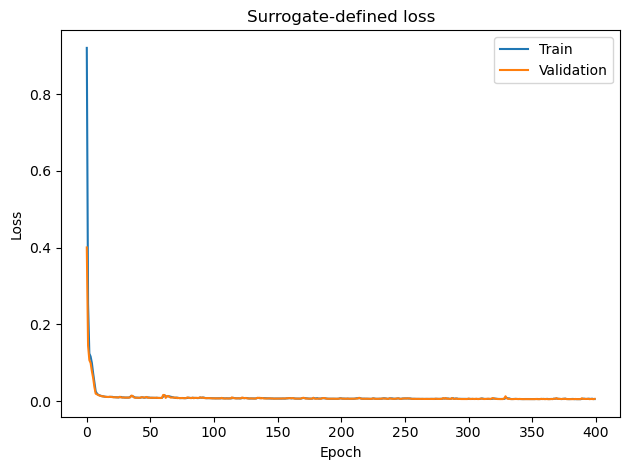

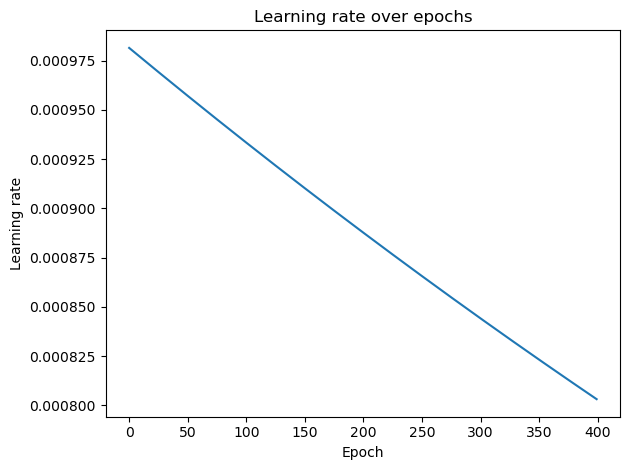

In [16]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and not VISUALIZE_GRADIENTS:
    class LearningRateMonitor(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.learning_rates = []
        def on_epoch_end(self, epoch, logs=None):
            lr = self.model.optimizer.learning_rate
            if callable(lr):
                lr = lr(self.model.optimizer.iterations)
            self.learning_rates.append(float(tf.keras.backend.get_value(lr)))

    best_hp = tuner.get_best_hyperparameters(1)[0]
    model = tuner.hypermodel.build(best_hp)
    lr_monitor = LearningRateMonitor()
    history = model.fit(
        np.asarray(X_train), [np.asarray(X_train), dummy_y_train],
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), [np.asarray(X_val), dummy_y_val]),
        callbacks=[early_stopping, lr_monitor], verbose=1)
    del model
    tf.keras.backend.clear_session()
    gc.collect()

if history is not None and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Surrogate-defined loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='best')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/surrogate_loss_history.pdf')
    plt.show()

    plt.plot(lr_monitor.learning_rates)
    plt.title('Learning rate over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Learning rate')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/surrogate_loss_learning_rate.pdf')
    plt.show()

### Test set evaluation

In [17]:
if not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    ## evaluate on test set
    tf.keras.backend.clear_session()
    gc.collect()

    def get_loss(eval_out):
        if isinstance(eval_out, dict):
            return float(eval_out.get('loss', list(eval_out.values())[0]))
        if isinstance(eval_out, (list, tuple, np.ndarray)):
            return float(eval_out[0])
        return float(eval_out)

    combined_model = load_model(
        best_model_file,
        compile=False,
        custom_objects={'ScalerConversionLayer': ScalerConversionLayer},
    )
    combined_model.compile(
        optimizer='adam',
        loss=[TRAIN_LOSS, qiskit_range_penalty],
        loss_weights=[1.0, PENALTY_WEIGHT],
    )
    eval_result = combined_model.evaluate(
        np.asarray(X_test),
        [np.asarray(X_test), dummy_y_test],
    )
    total_loss = float(eval_result[0])
    Hamiltonian_recon_loss = float(eval_result[1])
    penalty_loss = float(eval_result[2])

    print(f'Total test loss {total_loss}')
    print(f'Reconstruction loss ({TRAIN_LOSS}) {Hamiltonian_recon_loss}')
    print(f'Range penalty loss {penalty_loss} weighted {penalty_loss * PENALTY_WEIGHT}')

    inverse_model = combined_model.get_layer('inverse_model')
    qiskit_pred = inverse_model.predict(np.asarray(X_test), verbose=0)
    out_of_range = np.sum((qiskit_pred < 0) | (qiskit_pred > 1))
    total_values = qiskit_pred.size
    print(f'Out of range values {out_of_range}/{total_values} ({100*out_of_range/total_values:.1f}%)')

    test_loss_result = Hamiltonian_recon_loss

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - inverse_model_loss: 4.6619e-05 - loss: 0.0051 - sequential_loss: 9.0754e-04
Total test loss 0.005063109565526247
Reconstruction loss (mae) 0.0009075350244529545
Range penalty loss 4.661868297262117e-05 weighted 4.661868297262118e-06
Out of range values 47/873 (5.4%)


### Save test summary

In [18]:
if not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    summary_path = Path(RESULTS_DIR) / 'training' / 'test_results.csv'
    summary_path.parent.mkdir(parents=True, exist_ok=True)
    csv_data = [[
        DATA_AUGMENTATION,
        'surrogate_loss_model',
        'InverseModel_SurrogateLoss',
        test_loss_result,
        TRAIN_LOSS,
        TRAIN_BATCH_SIZE,
    ]]
    with summary_path.open('a', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(csv_data)
    print(f'Appended test summary to {summary_path}')

Appended test summary to /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/training/test_results.csv
